In [34]:
import matplotlib.pyplot as plt

import microbial_thermo as mt
from microbial_thermo.balance import infer_couples
from microbial_thermo.figures import plot_energy_explorer, plot_half_reactions, plot_redox_tower
from microbial_thermo.supplemental import supplemental_species
entry = supplemental_species()["NH2OH(aq)"]


{'NH2OH(aq)': SupplementalSpecies(backend='NH2OH(aq)', formula='NH3O', delta_Gf_kJ_mol=-23.5, temperature_c=25.0, delta_Hf_kJ_mol=-98.9, display='NH_2OH', phase='aq', smiles=None, aliases=('hydroxylamine', 'NH2OH', 'NH2OH(aq)'), verified=False, provenance='Commonly cited value for aqueous hydroxylamine; NOT yet traced to a primary source. Central nitrification intermediate, absent from every pyGCC database. CHECK BEFORE USE.'),
 'Glucose(aq)': SupplementalSpecies(backend='Glucose(aq)', formula='C6H12O6', delta_Gf_kJ_mol=-917.2, temperature_c=25.0, delta_Hf_kJ_mol=None, display='glucose', phase='aq', smiles='OCC1OC(O)C(O)C(O)C1O', aliases=('glucose', 'dextrose', 'C6H12O6'), verified=False, provenance='Commonly cited value for aqueous D-glucose; sources differ by a few kJ/mol (roughly -915 to -919). NOT yet traced to a primary source. CHECK BEFORE USE.'),
 'Pyruvate(aq)': SupplementalSpecies(backend='Pyruvate(aq)', formula='C3H3O3-', delta_Gf_kJ_mol=-474.5, temperature_c=25.0, delta_Hf_k

In [40]:
EQUATION = "VO+2 + SO42− + H2 -> VOSO4(aq)"
conditions = mt.Conditions(temperature_c=25.0, pH=7)
reaction = mt.Reaction.from_equation(EQUATION, conditions=conditions)
print(reaction.summary())

SpeciesNotFoundError: species 'VO+2' not found in the thermodynamic database; did you mean: O2(aq), FeOH++?

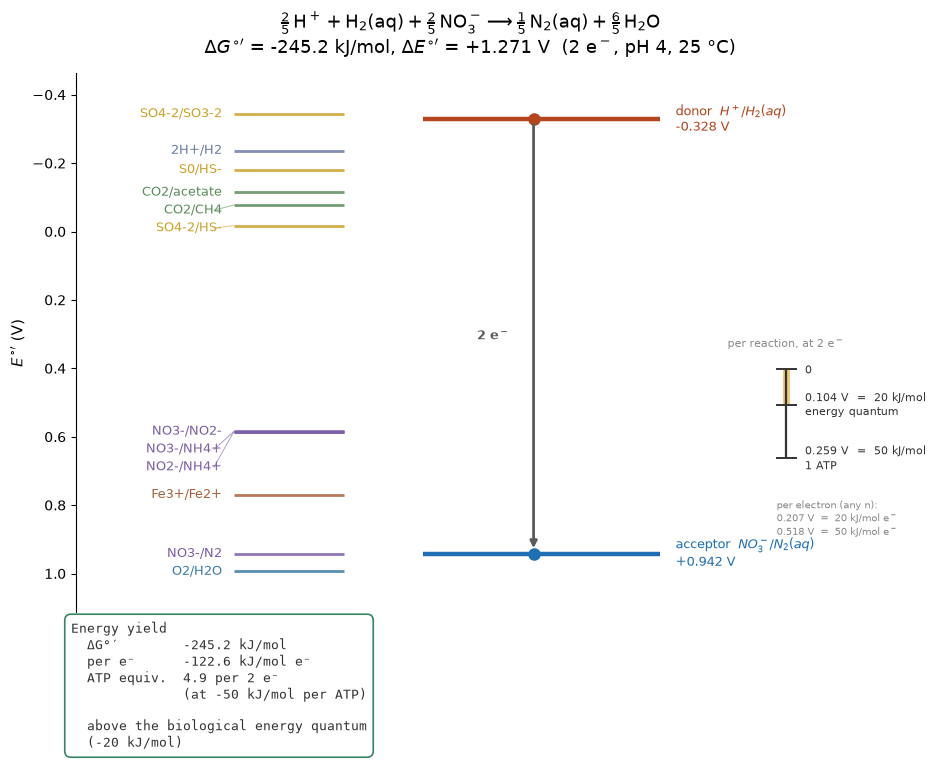

In [30]:
p = plot_redox_tower(reaction)

In [31]:
reaction.acceptor_half.couple.oxidized.backend, \
reaction.acceptor_half.couple.reduced.backend, \
reaction.donor_half.couple.oxidized.backend, \
reaction.donor_half.couple.reduced.backend

('NO3-', 'N2(aq)', 'H+', 'H2(aq)')

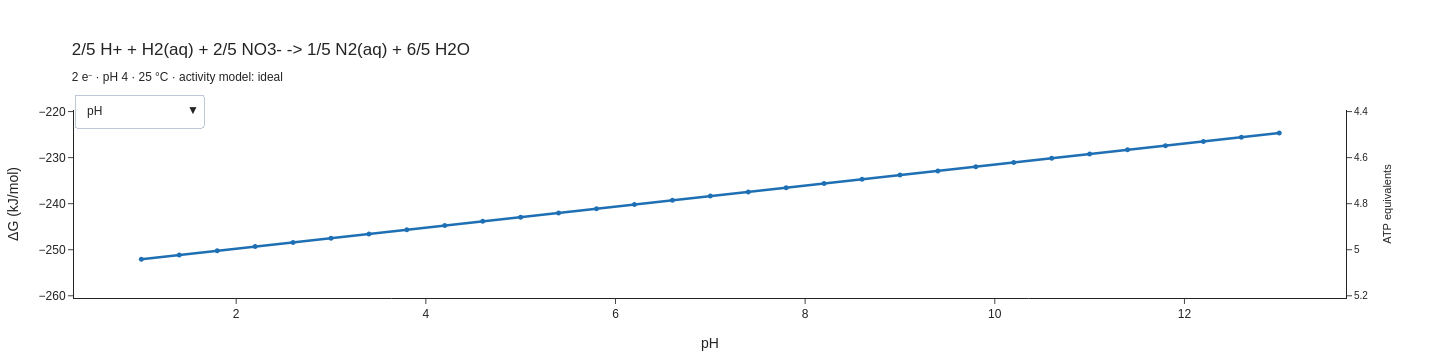

In [32]:
from microbial_thermo.sweep import concentration_axis, partial_pressure_axis, ph_axis

axes = [
    ph_axis(low=1.0, high=13.0, n=31),
    concentration_axis(reaction.acceptor_half.couple.oxidized.backend),
    concentration_axis(reaction.acceptor_half.couple.reduced.backend),
    partial_pressure_axis(reaction.donor_half.couple.reduced.backend), 
    partial_pressure_axis(reaction.donor_half.couple.oxidized.backend), 
]
figure = plot_energy_explorer(reaction, axes=axes)

figure.show()